# Machine-Learning Lab

## Name:Soham Thakre

## Class:B_B1

## Roll No:09

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
df=pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
if 'Address' in df.columns:
    df.drop(['Address'], axis=1, inplace=True)

In [4]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [5]:
pd.set_option('display.float_format','{:2f}'.format)

In [6]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64

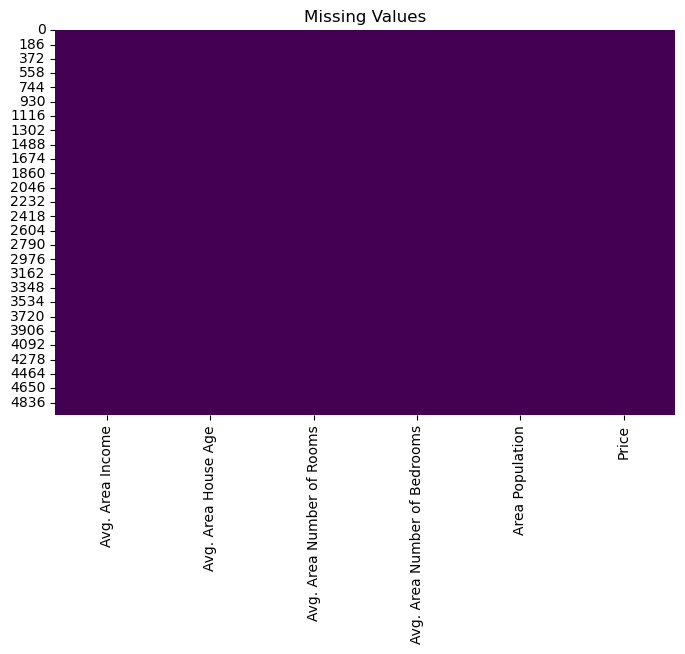

In [7]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values")
plt.show()

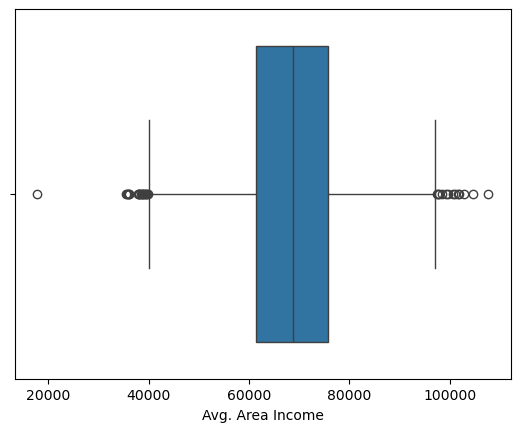

In [8]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

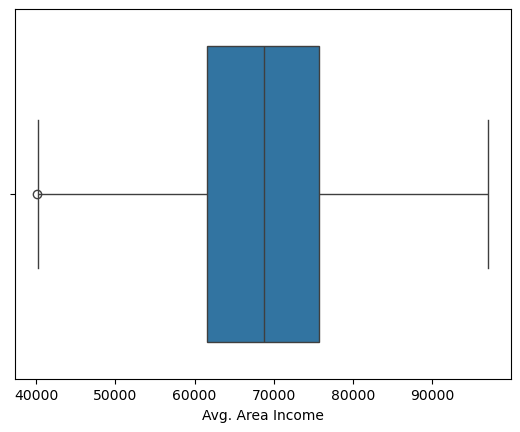

In [9]:
Q1=df["Avg. Area Income"].quantile(0.25)
Q3=df["Avg. Area Income"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Avg. Area Income"]>=lower) & (df["Avg. Area Income"]<=upper)]
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

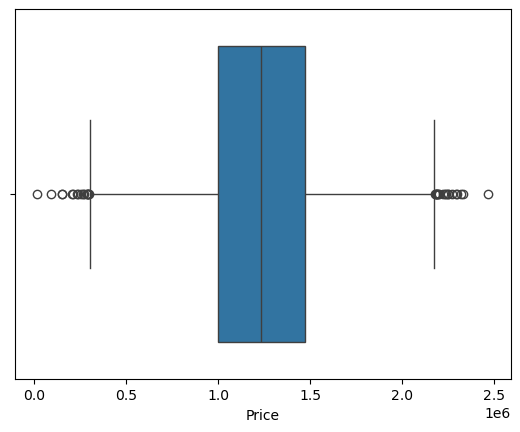

In [10]:
sns.boxplot(x=df["Price"])
plt.show()

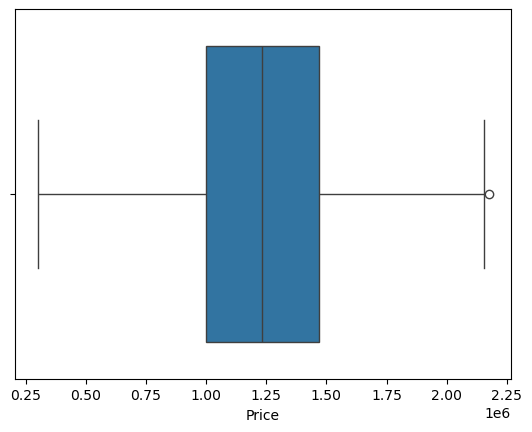

In [11]:
Q1=df["Price"].quantile(0.25)
Q3=df["Price"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Price"]>=lower) & (df["Price"]<=upper)]
sns.boxplot(x=df["Price"])
plt.show()

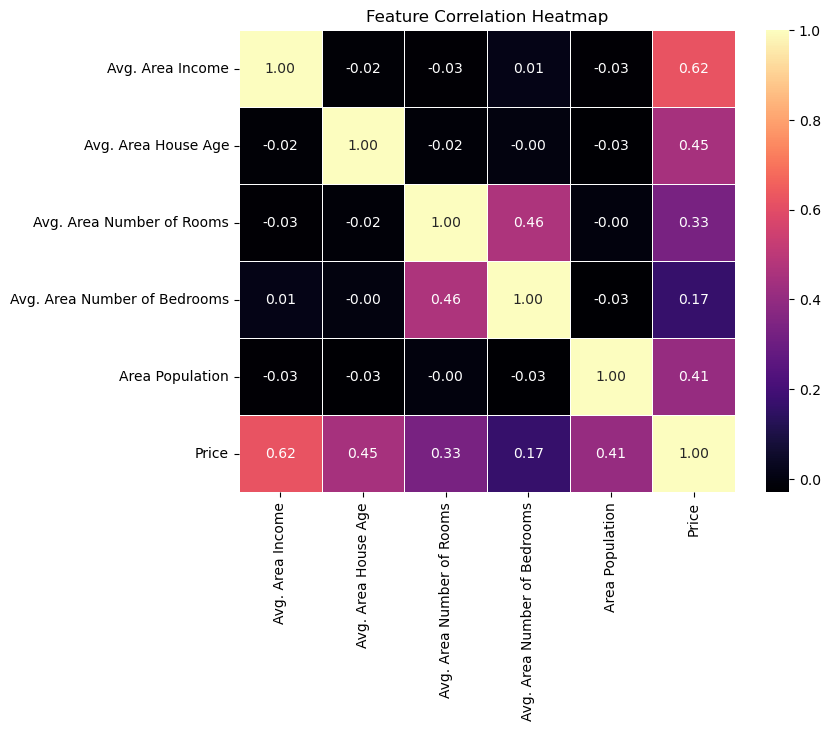

In [12]:
plt.figure(figsize=(8,6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='magma',annot=True, fmt=".2f",linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

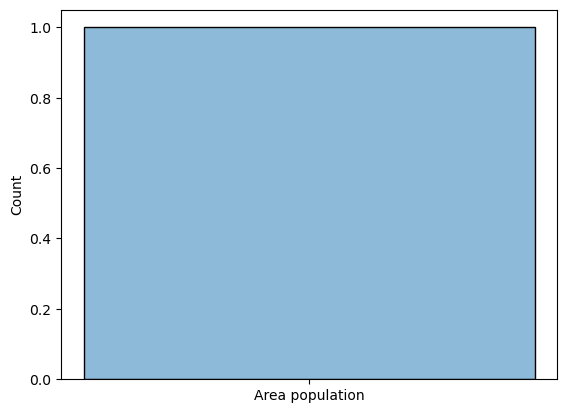

In [13]:
sns.histplot(["Area population"],kde=True)
plt.show()

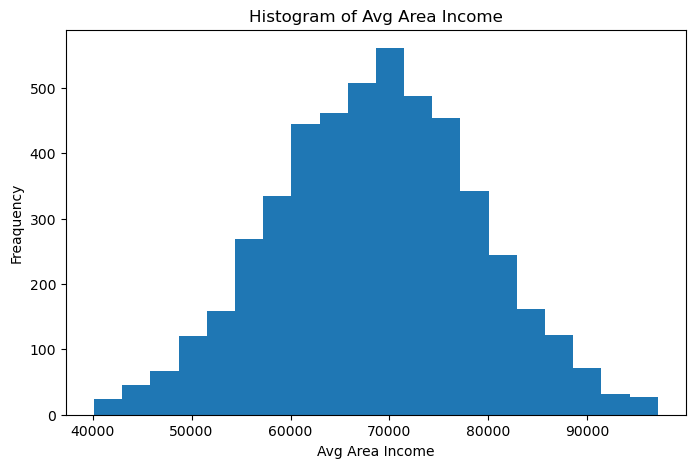

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Avg. Area Income'], bins=20)
plt.title('Histogram of Avg Area Income')
plt.xlabel('Avg Area Income')
plt.ylabel('Freaquency')
plt.show()

# SLR

In [15]:
X= df[['Avg. Area Income']]
y = df['Price']

In [16]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.linear_model import LinearRegression 
slr_model = LinearRegression()
slr_model.fit(X_train,y_train)

LinearRegression()

In [18]:
y_pred = slr_model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

print("Simple Linear Regression")
print("-------------------------")
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("R2 Score: ",r2_score(y_test, y_pred))

Simple Linear Regression
-------------------------
MAE:  216087.7143550425
MSE:  70880962067.4512
RMSE:  266234.7874855035
R2 Score:  0.3983053580403858


In [20]:
print("Intercept:",slr_model.intercept_)
print("Slope:", slr_model.coef_[0])

Intercept: -174255.61105124233
Slope: 20.47908507312436


In [21]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

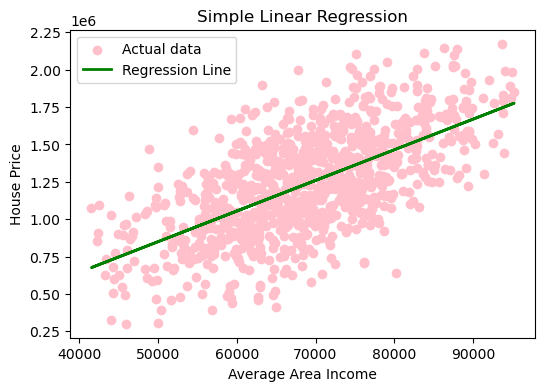

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(X_test,y_test, color='pink',label='Actual data')
plt.plot(X_test, y_pred,color='green', linewidth=2,label='Regression Line')
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [23]:
income = float(input("Enter Avg Area Income"))
new_data = np.array([[income]])
prediction = slr_model.predict(new_data)
print("Predicted House Price =${:,.2f}".format(prediction[0]))

Enter Avg Area Income 90000


Predicted House Price =$1,668,862.05


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Multiple Linear Regression

In [28]:
X=df.drop(["Price"],axis=1)

y=df["Price"]

In [29]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

y_pred = mlr_model.predict(X_test)

In [42]:
mlr=LinearRegression()

mlr.fit(X_train,y_train)

LinearRegression()

In [43]:
coef=pd.DataFrame(
    mlr.coef_,
    X.columns,
    columns=["Coefficient"])
coef

,Coefficient
Avg. Area Income,21.534357
Avg. Area House Age,165086.642447
Avg. Area Number of Rooms,121071.088534
Avg. Area Number of Bedrooms,1327.604145
Area Population,14.979608


In [44]:
y_pred=mlr.predict(X_test)

In [45]:
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score: ",r2_score(y_test, y_pred))

MAE:  78456.94223112603
MSE:  9643840322.408455
RMSE:  98203.05658383784
R2 Score:  0.918135323214358


In [46]:
predictions = mlr_model.predict(X_test)

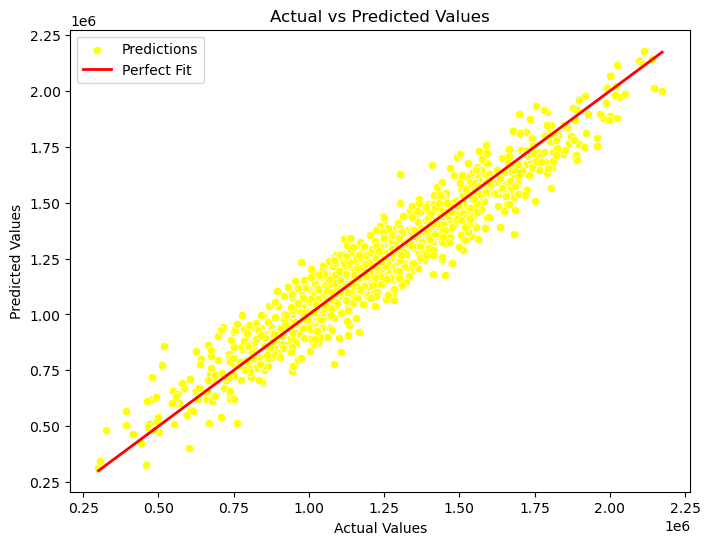

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=predictions,color='yellow',label='Predictions')
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)], color='red',linewidth=2,label='Perfect Fit')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

In [48]:
income = float(input("Enter Average Area Income: "))
house_age = float(input("Enter Average Area House Age: "))
rooms = float(input("Enter Average Area Number Of rooms: "))
bedrooms = float(input("Enter Average number of bedrooms: "))
population = float(input("Enter Area Population: "))
input_array = [[income,house_age,rooms,bedrooms, population
]]
predicted_price = mlr_model.predict(input_array)

print("Predicted House Price: ${:,.2f}".format(predicted_price[0]))

Enter Average Area Income:  1234
Enter Average Area House Age:  23455
Enter Average Area Number Of rooms:  3567
Enter Average number of bedrooms:  435678
Enter Area Population:  245678


Predicted House Price: $4,883,456,643.86


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Ridge Regression

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
param_grid={'alpha' : [0.001,0.01,0.1,10,100]}

In [52]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [54]:
# Alpha values
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [55]:
grid_ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring='r2',
    cv=5
)

In [56]:
# Train the model
grid_ridge.fit(X_train, y_train)

# Best Alpha and Best Score
print("Best Alpha:", grid_ridge.best_params_)

Best Alpha: {'alpha': 1}


# Lasso Regression

In [58]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [57]:
from sklearn.linear_model import Lasso
param_grid={'alpha':[0.001,0.01,0.1,1,10]}

In [59]:
grid_lasso=GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')

grid_lasso.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [60]:
print(grid_lasso.best_params_)

{'alpha': 0.001}


In [61]:
lasso_pred=grid_lasso.predict(X_test)

print(r2_score(y_test,lasso_pred))

0.9181353232692439


In [63]:
predictions=mlr_model.predict(X_test)

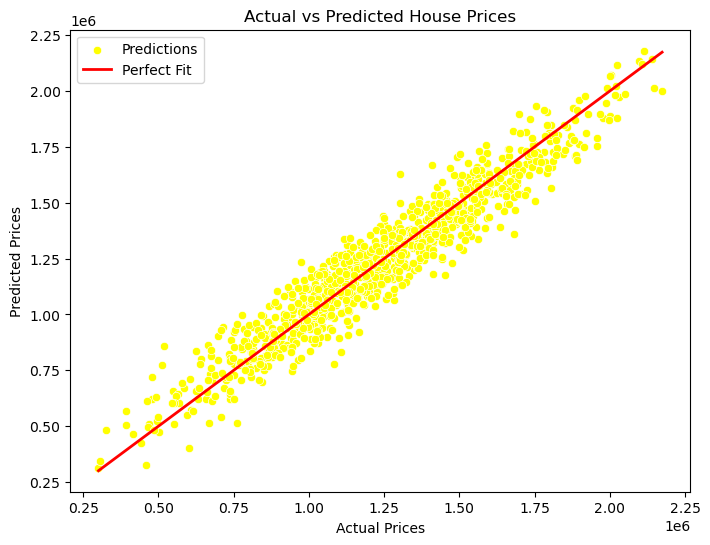

In [64]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=predictions,color='yellow',label='Predictions')

# Add a reference line (perfect prediction line))
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linewidth=2,label='Perfect Fit')

#Add Labels and Legend
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.show()